In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:

drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


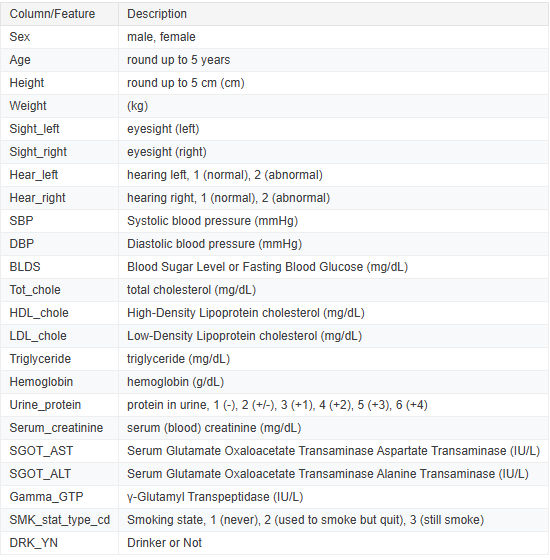

In [6]:
drinking_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.614491,14.181339,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.240625,9.282957,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.284050,12.514241,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.233358,11.850323,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.980834,0.605949,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.978429,0.604774,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.031495,0.174650,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.030476,0.171892,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.432498,14.543148,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.052627,9.889365,32.0,70.0,76.0,82.0,185.0


In [7]:
drinking_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

In [8]:
any_null = drinking_df.isna().sum().sum()
print("Any missing values:", any_null)

Any missing values: 0


In [9]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Antall duplikater som ville blitt droppet: {num_duplicates}")
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Antall duplikater som ville blitt droppet: 26
Prosent beholdt: 99.9973773032%


In [10]:
import pandas as pd
from termcolor import colored

def grab_col_names(dataframe, cat_th=10, car_th=20):

    # Kategoriske kolonner (dtype = object)
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    # Numeriske, men egentlig kategoriske (få unike verdier)
    num_but_cat = [col for col in dataframe.columns 
                   if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]

    # Kategoriske, men egentlig kardinale (mange unike verdier)
    cat_but_car = [col for col in dataframe.columns 
                   if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    # Kombiner ekte kategoriske og numeriske som er kategoriske
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # Numeriske kolonner (ekskluder de som er klassifisert som kategoriske)
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(drinking_df_unique)

print(f"\nNumerical Columns: {num_cols}\n")
print(f"Categorical Columns: {cat_cols}\n")
     


Observations: 991320
Variables: 24
cat_cols: 6
num_cols: 18
cat_but_car: 0
num_but_cat: 4

Numerical Columns: ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

Categorical Columns: ['sex', 'DRK_YN', 'hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']



In [11]:
import pandas as pd

# Antar at datasettet ditt heter drinking_df (eller drinking_df_unique)
df = drinking_df_unique.copy()

# Velg kategoriske kolonner (dtype = object eller category)
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Skriv ut antall unike og hvilke verdier for hver kolonne
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"Kolonne: {col}")
    print(f"Antall unike verdier: {df[col].nunique()}")
    print(f"Unike verdier: {unique_vals}")
    print("-" * 50)


Kolonne: sex
Antall unike verdier: 2
Unike verdier: ['Male' 'Female']
--------------------------------------------------
Kolonne: DRK_YN
Antall unike verdier: 2
Unike verdier: ['Y' 'N']
--------------------------------------------------


In [12]:
drinking_df_unique

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
vi vil ikke fjerne outliers ifra alle eksmeplvis protien in urin her må vi skrive om hva data betyr i teskten 

In [13]:
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ['sex', 'hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']

# Funksjon for å beregne sannsynlighet for å drikke (DRK_YN = Y)
def drinking_prob_by_category(data, cat_cols, target="DRK_YN", positive="Y"):
    results = {}
    for col in cat_cols:
        if col == target:  # hopper over selve target
            continue
        # Krysstabell med sannsynlighet
        ct = pd.crosstab(data[col], data[target], normalize="index") * 100
        if positive in ct.columns:
            results[col] = ct[positive]
        else:
            results[col] = pd.Series(0, index=ct.index)  # fallback hvis Y ikke finnes
    return results

results = drinking_prob_by_category(df, cat_cols)

# Print resultater
for col, probs in results.items():
    print(f"\nSannsynlighet for å drikke (DRK_YN='Y') gitt {col}:")
    print(probs.round(2).astype(str) + " %")



Sannsynlighet for å drikke (DRK_YN='Y') gitt sex:
sex
Female    30.36 %
Male      67.31 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt hear_left:
hear_left
1.0    50.51 %
2.0    33.81 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt hear_right:
hear_right
1.0     50.5 %
2.0    33.56 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt urine_protein:
urine_protein
1.0    49.92 %
2.0    53.97 %
3.0    49.02 %
4.0    46.06 %
5.0    42.08 %
6.0     41.8 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt SMK_stat_type_cd:
SMK_stat_type_cd
1.0    35.43 %
2.0    68.86 %
3.0    75.52 %
Name: Y, dtype: object


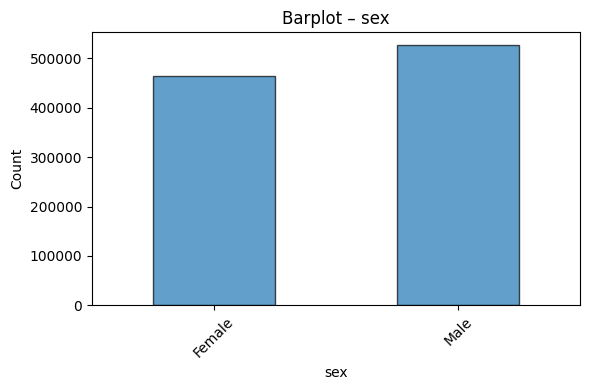

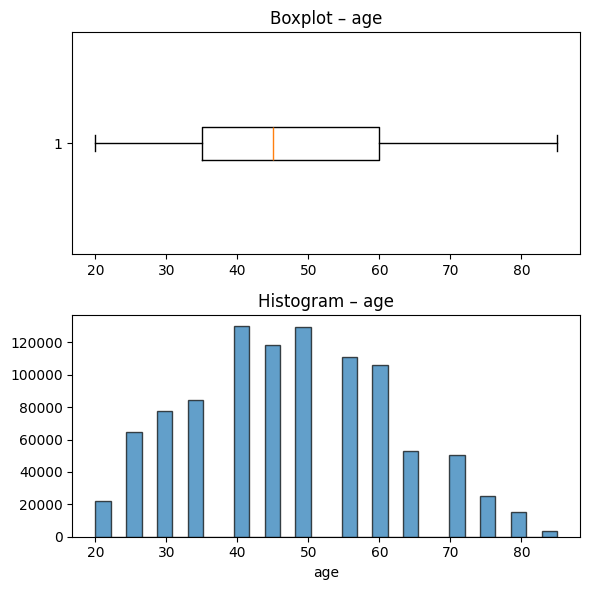

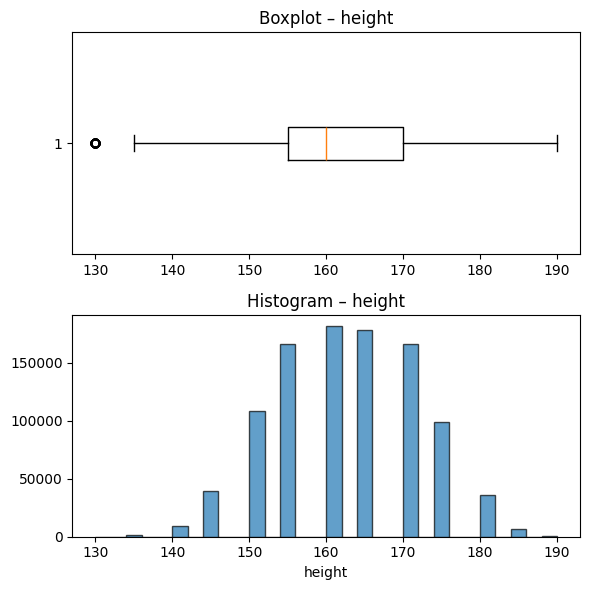

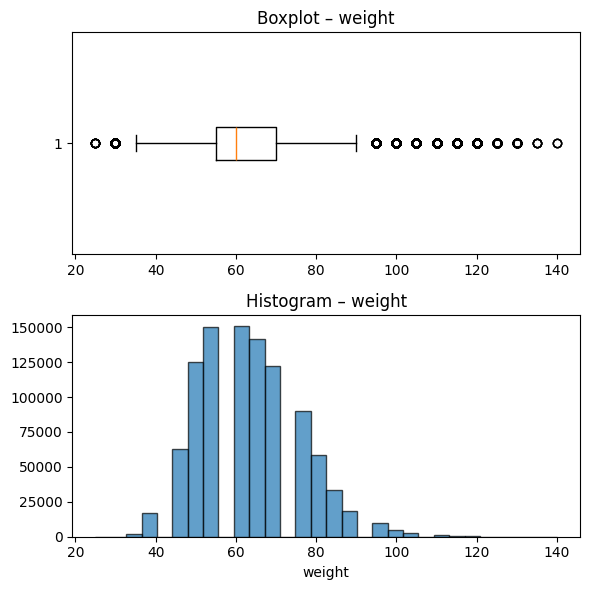

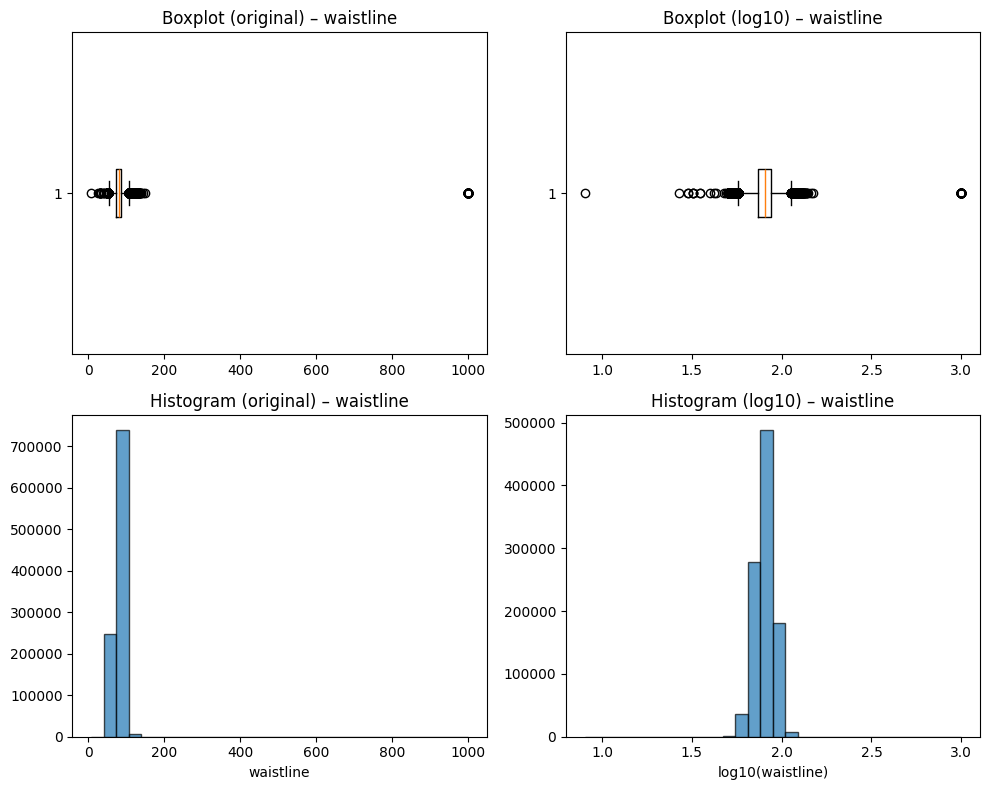

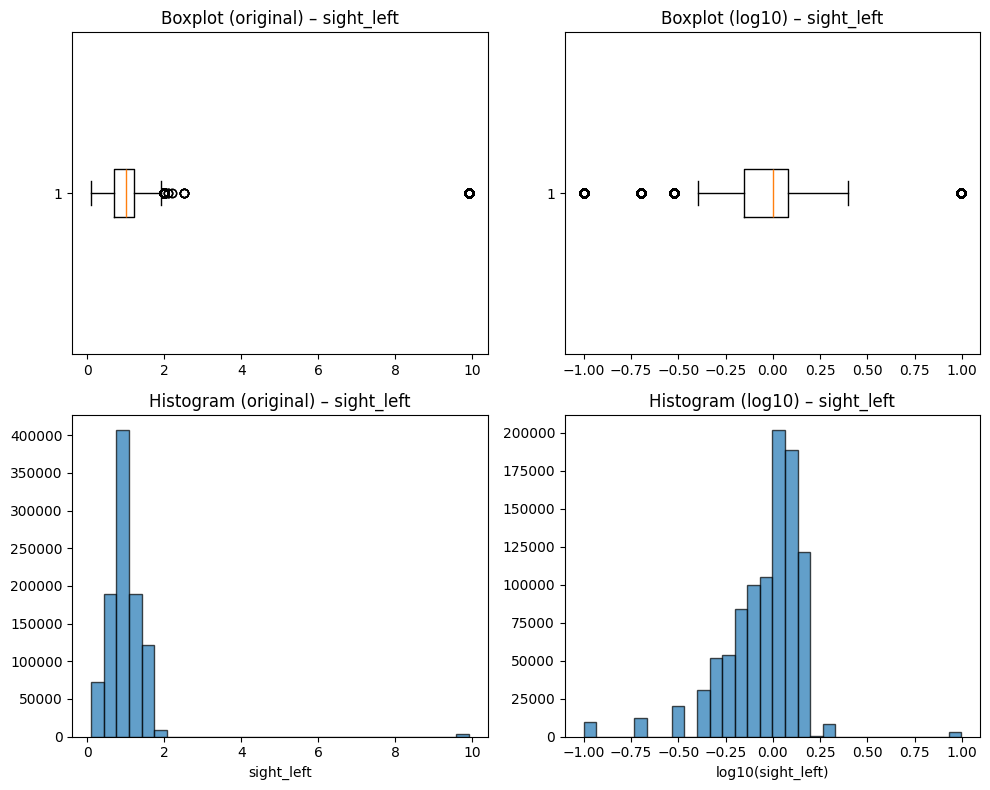

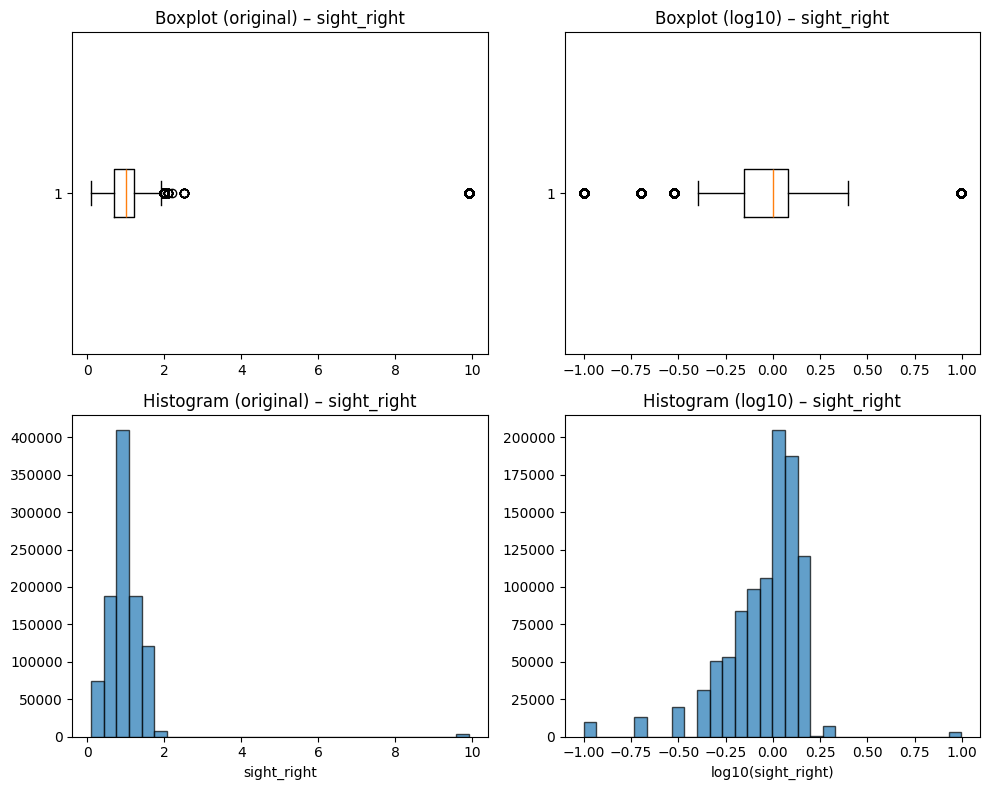

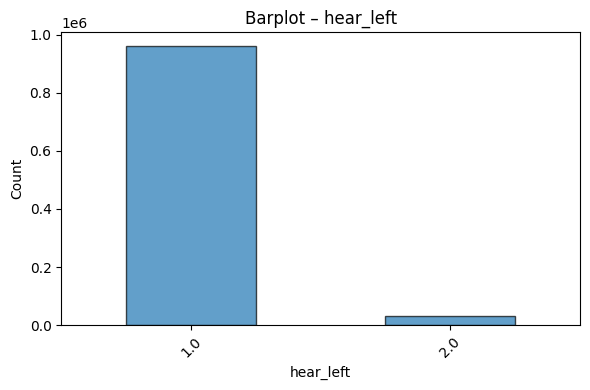

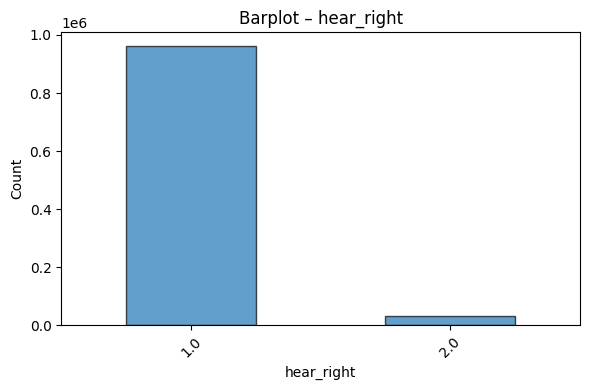

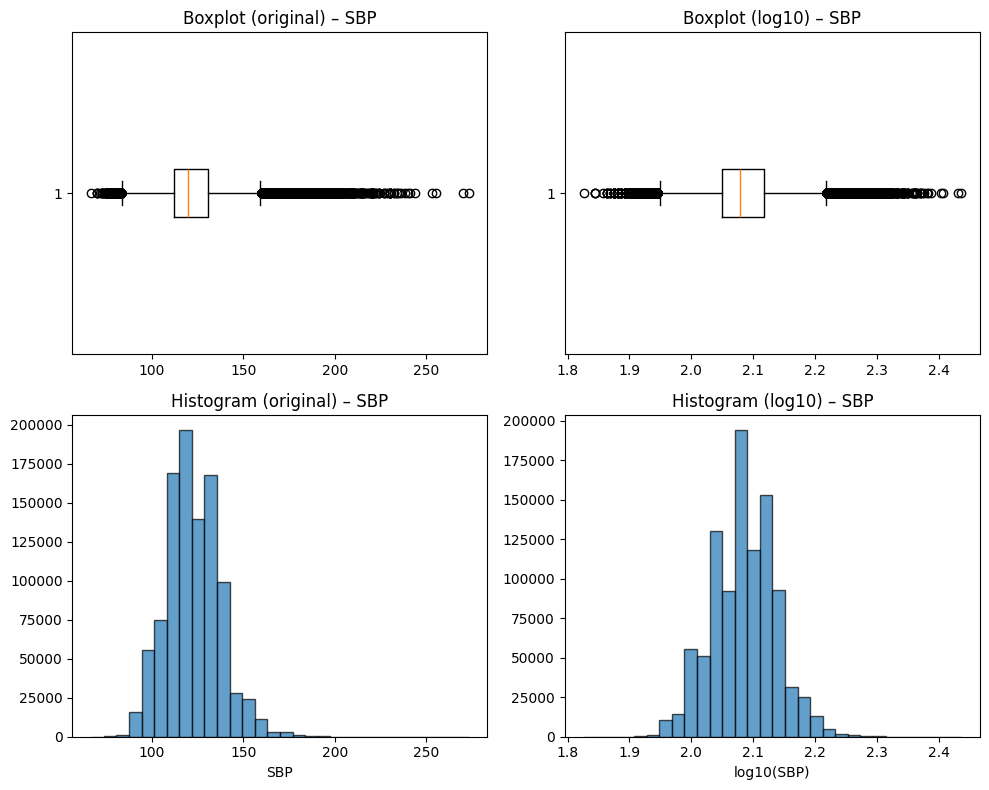

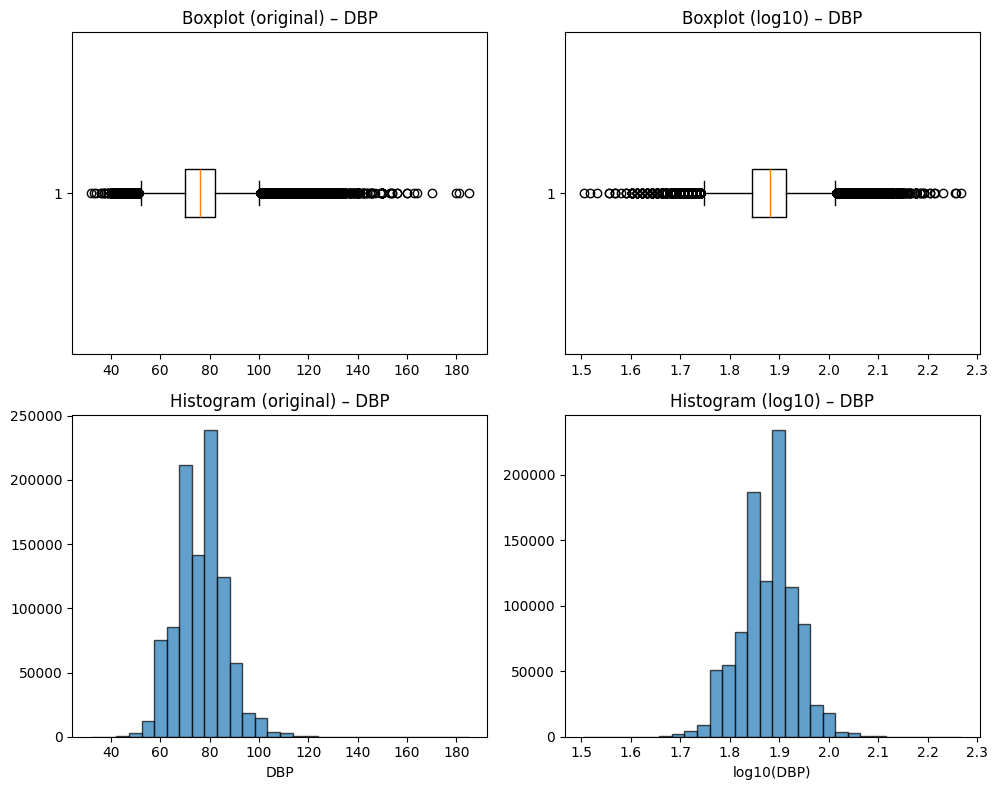

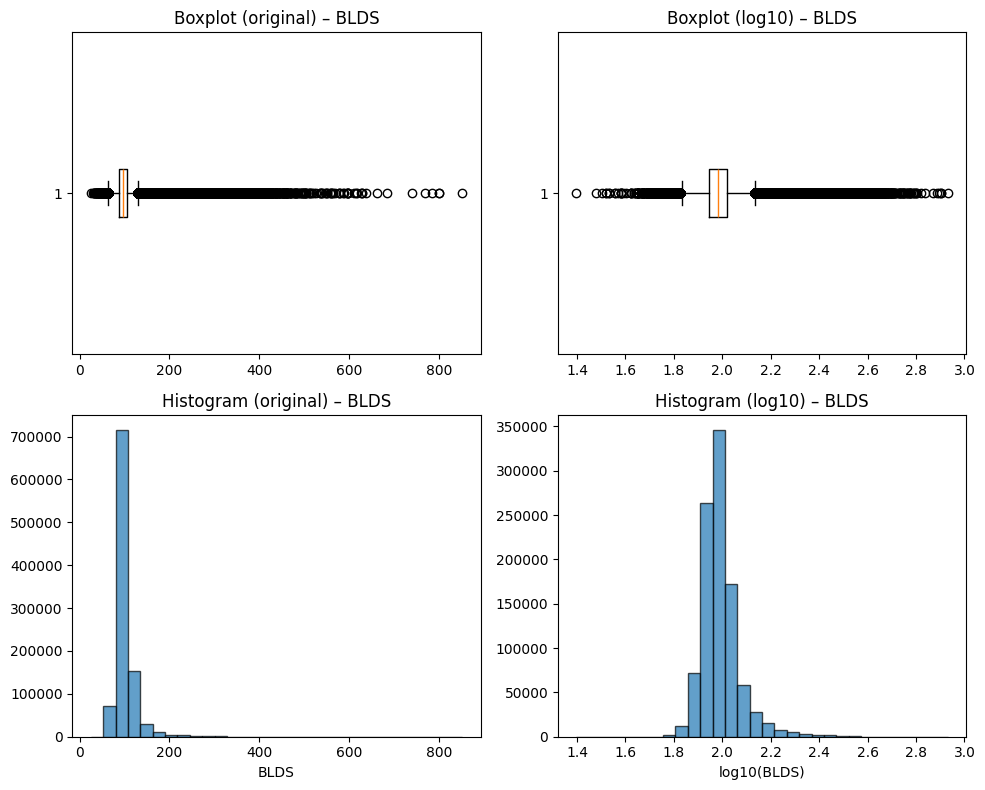

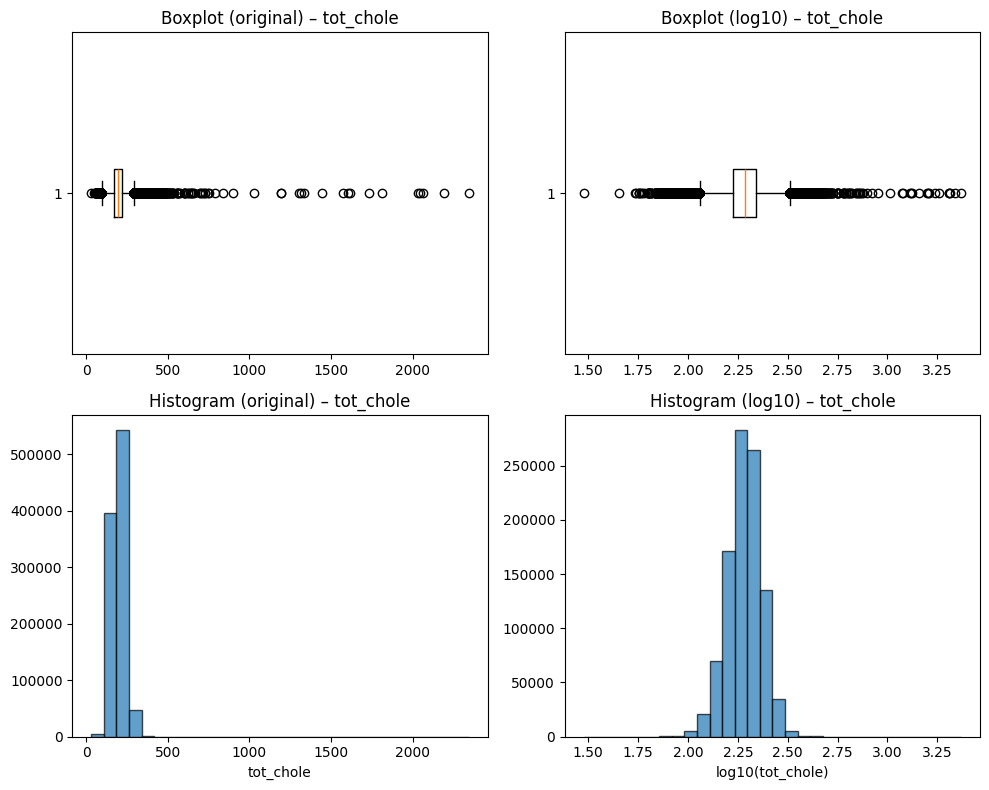

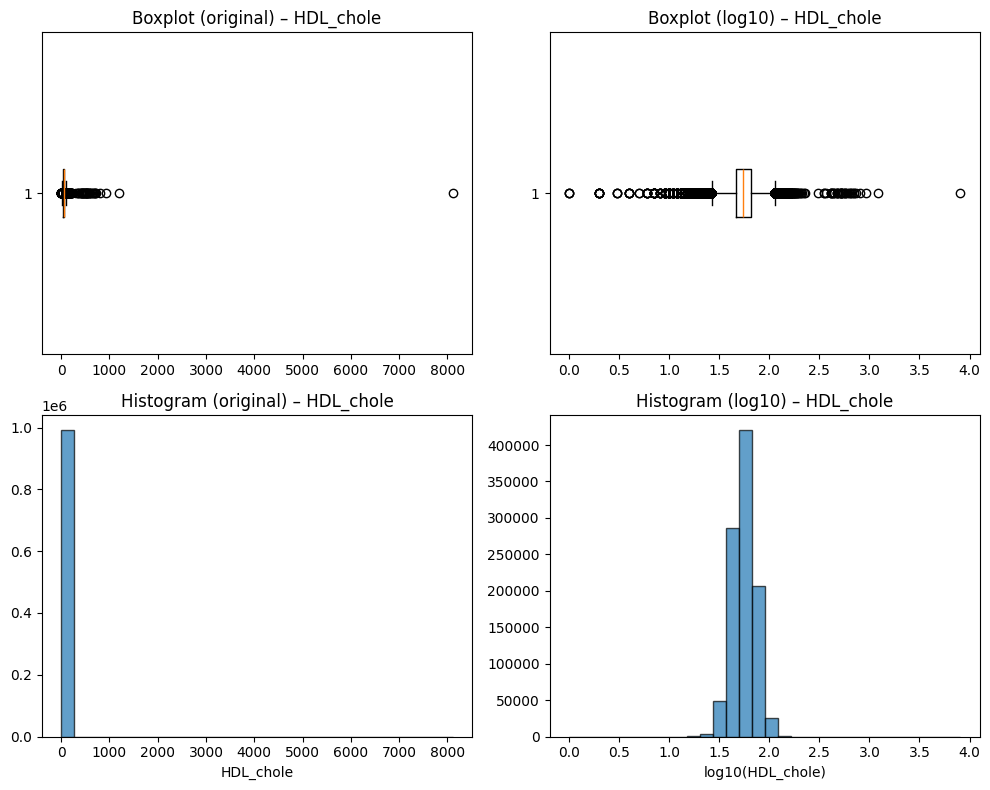

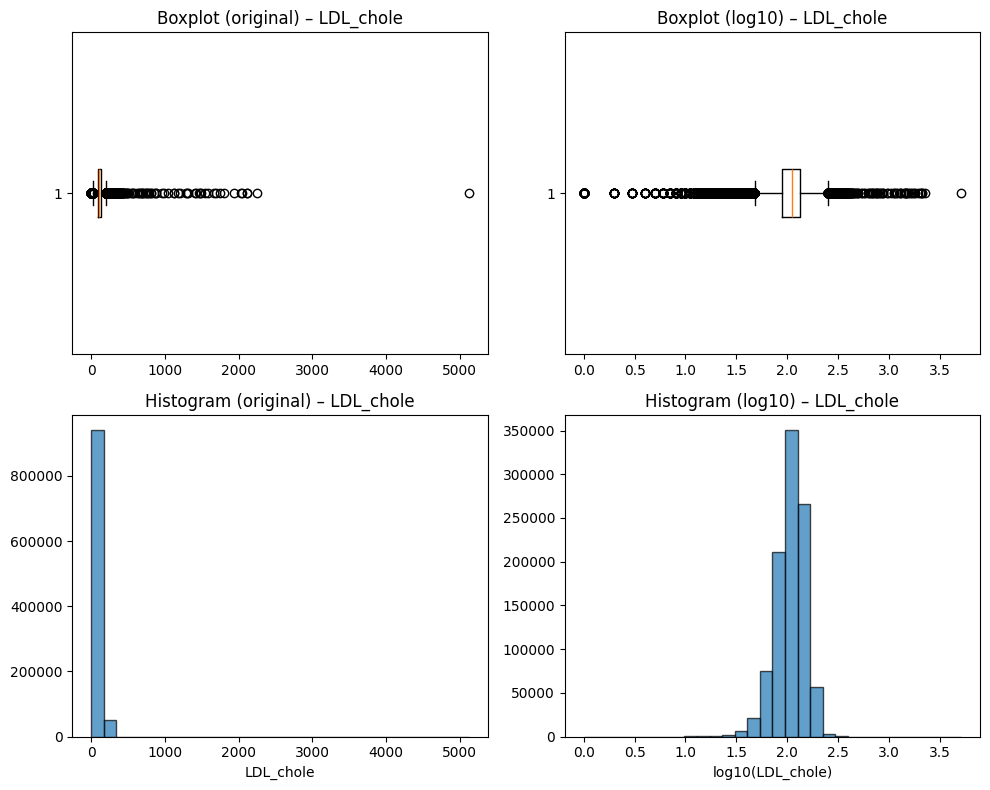

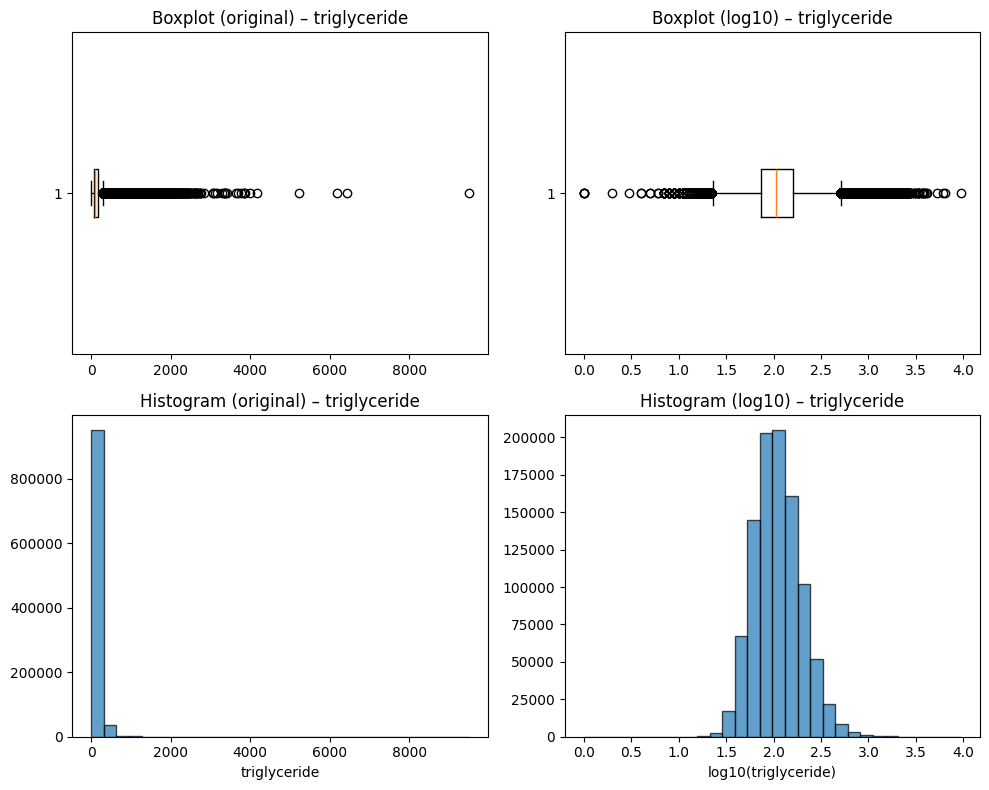

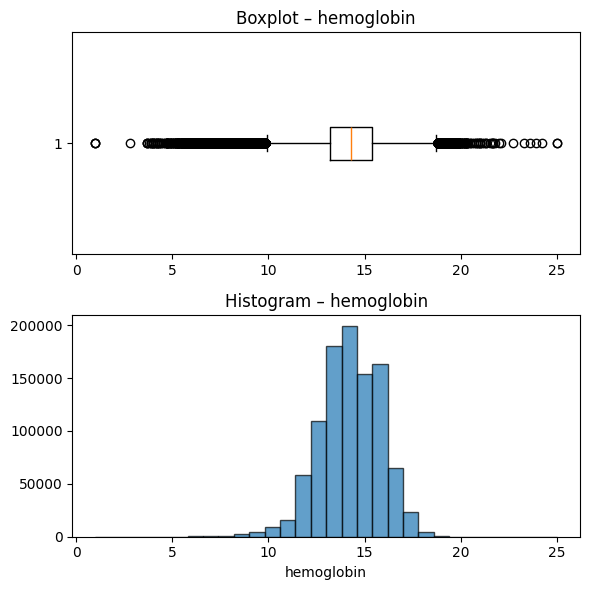

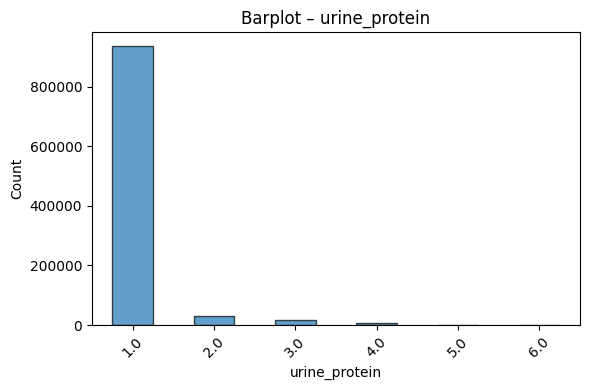

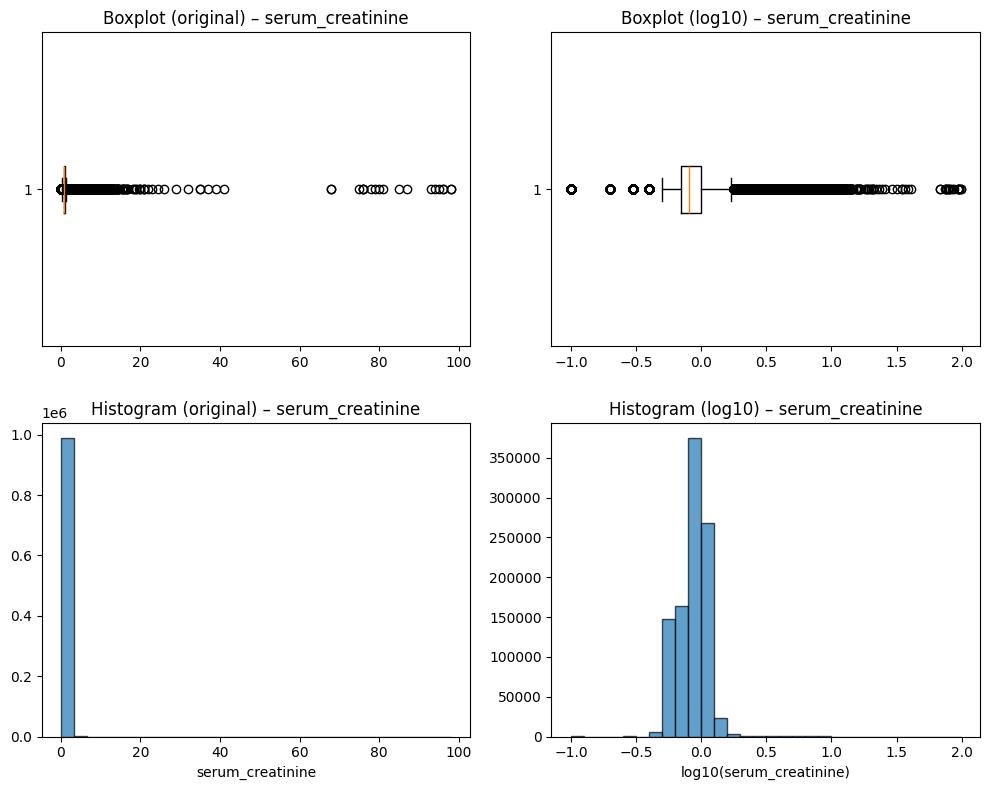

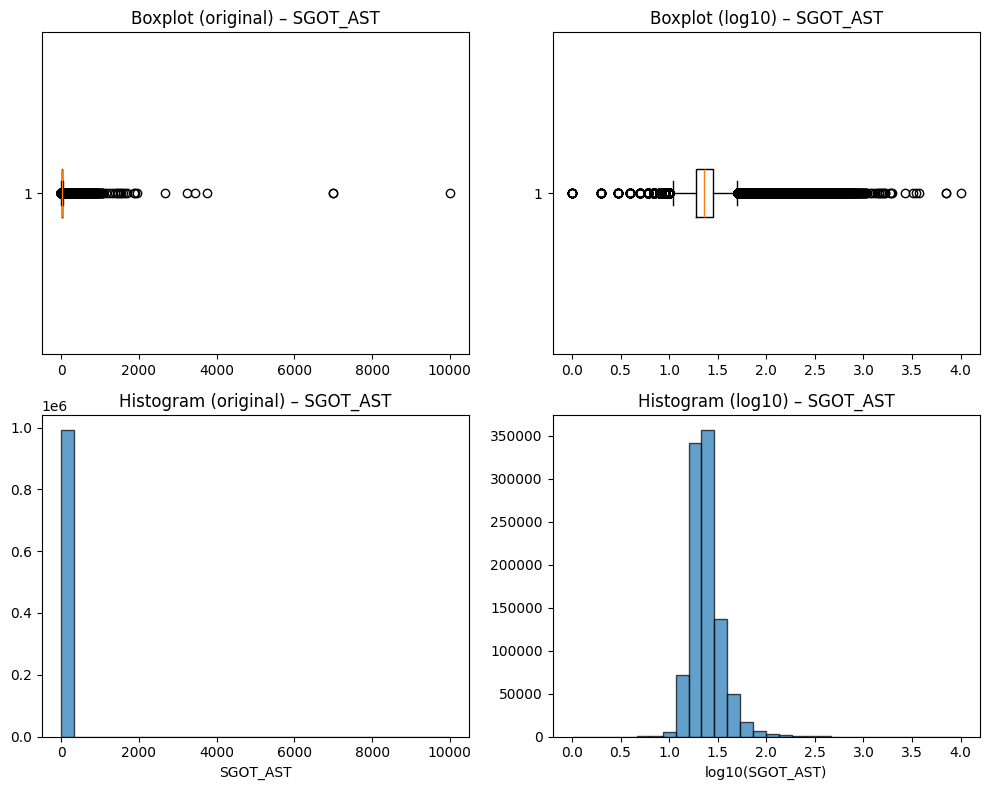

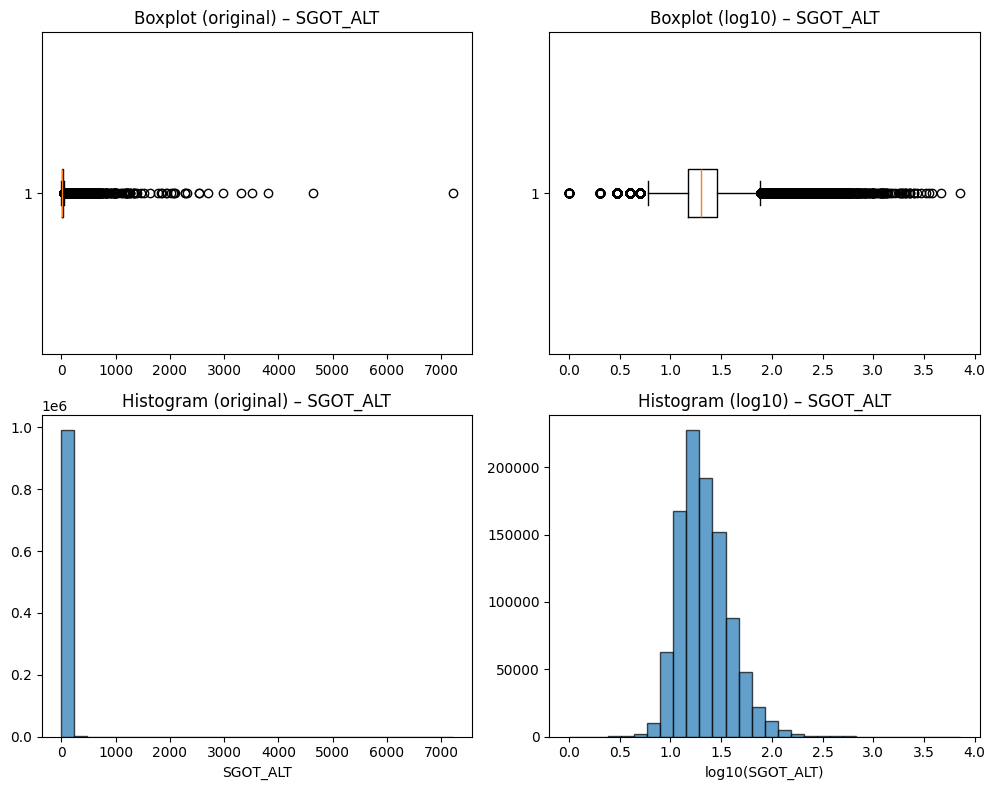

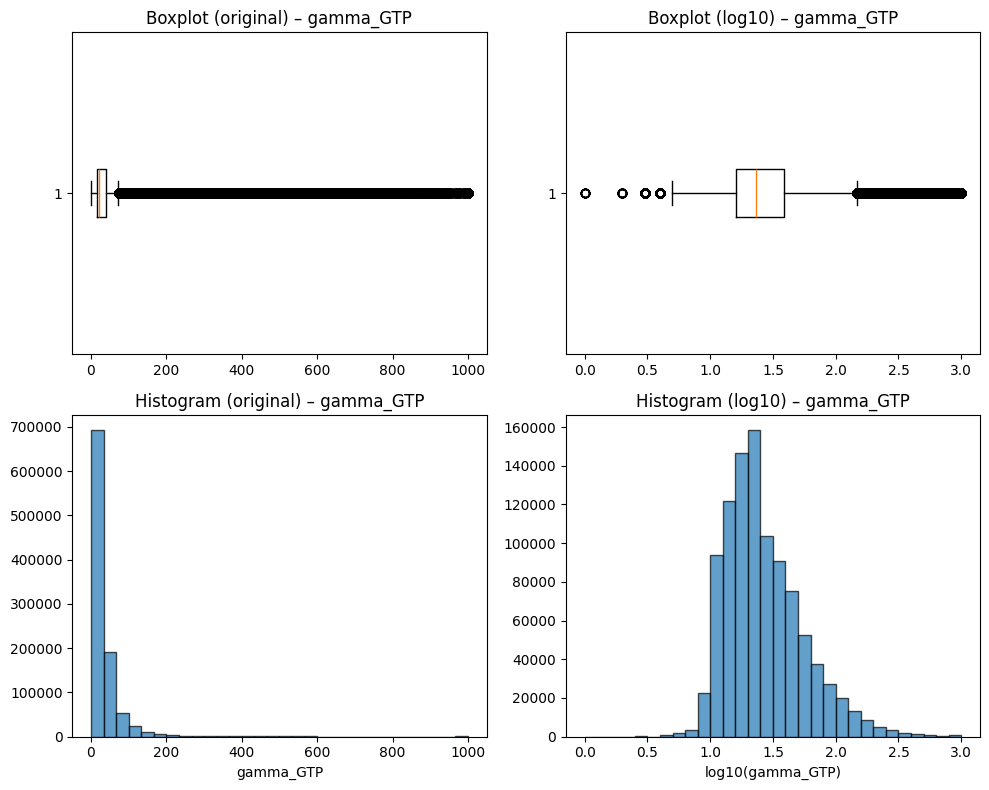

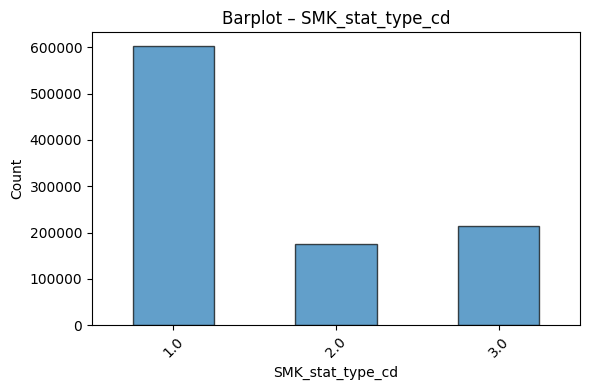

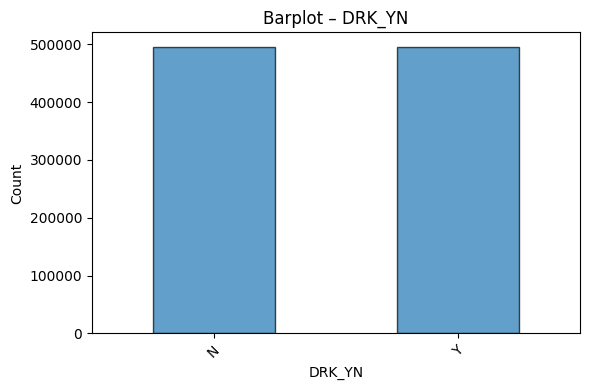

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

# Kopi av originalen – behold alt
df_log = df.copy()

def plot_with_optional_log(df, col, bins=30, allow_log=True):
    global df_log   
    
    data = df[col].dropna()
    if data.empty:
        return
    
    if col in cat_cols:
        counts = data.value_counts().sort_index()
        plt.figure(figsize=(6,4))
        counts.plot(kind="bar", edgecolor="black", alpha=0.7)
        plt.title(f"Barplot – {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        return
    
    # --- Hvis numerisk: log-transformer hvis lov ---
    log_data = None
    if allow_log and (data > 0).all():
        log_data = np.log10(data)
        df_log[col] = log_data   # overskriv i df_log
    
    if log_data is not None:
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        # Original
        axes[0,0].boxplot(data, vert=False, showfliers=True)
        axes[0,0].set_title(f"Boxplot (original) – {col}")
        axes[1,0].hist(data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1,0].set_title(f"Histogram (original) – {col}")
        axes[1,0].set_xlabel(col)
        # Log
        axes[0,1].boxplot(log_data, vert=False, showfliers=True)
        axes[0,1].set_title(f"Boxplot (log10) – {col}")
        axes[1,1].hist(log_data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1,1].set_title(f"Histogram (log10) – {col}")
        axes[1,1].set_xlabel(f"log10({col})")
    else:
        fig, axes = plt.subplots(2, 1, figsize=(6, 6))
        axes[0].boxplot(data, vert=False, showfliers=True)
        axes[0].set_title(f"Boxplot – {col}")
        axes[1].hist(data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1].set_title(f"Histogram – {col}")
        axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Kjør plotting for alle kolonner
for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    plot_with_optional_log(df, col, allow_log=allow_log)




In [15]:
df_log

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,1.954243,0.000000,0.000000,1.0,1.0,2.079181,...,2.100371,1.963788,17.1,1.0,0.000000,1.322219,1.544068,1.602060,1.0,Y
1,Male,30,180,80,1.949390,-0.045757,0.079181,1.0,1.0,2.113943,...,2.170262,2.082785,15.8,1.0,-0.045757,1.301030,1.556303,1.431364,3.0,N
2,Male,40,165,75,1.959041,0.079181,0.176091,1.0,1.0,2.079181,...,1.869232,2.017033,15.8,1.0,-0.045757,1.672098,1.505150,1.832509,1.0,N
3,Male,50,175,80,1.959041,0.176091,0.079181,1.0,1.0,2.161368,...,2.017033,2.025306,17.6,1.0,0.041393,1.462398,1.531479,1.255273,1.0,N
4,Male,50,165,60,1.903090,0.000000,0.079181,1.0,1.0,2.139879,...,2.068186,2.017033,13.8,1.0,-0.096910,1.278754,1.079181,1.397940,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,1.964260,0.176091,0.176091,1.0,1.0,2.056905,...,2.096910,2.120574,15.0,1.0,0.000000,1.414973,1.556303,1.431364,1.0,N
991342,Male,35,170,75,1.934498,0.000000,0.176091,1.0,1.0,2.075547,...,1.924279,1.653213,15.8,1.0,0.041393,1.146128,1.230449,1.176091,1.0,N
991343,Female,40,155,50,1.832509,0.000000,-0.154902,1.0,1.0,2.041393,...,1.886491,2.195900,14.3,1.0,-0.096910,1.477121,1.431364,1.230449,3.0,Y
991344,Male,25,175,60,1.857332,0.176091,0.000000,1.0,1.0,2.075547,...,1.863323,1.724276,14.5,1.0,-0.096910,1.322219,1.146128,1.230449,1.0,N


Antall rader før: 991320, etter fjerning av outliers: 877018


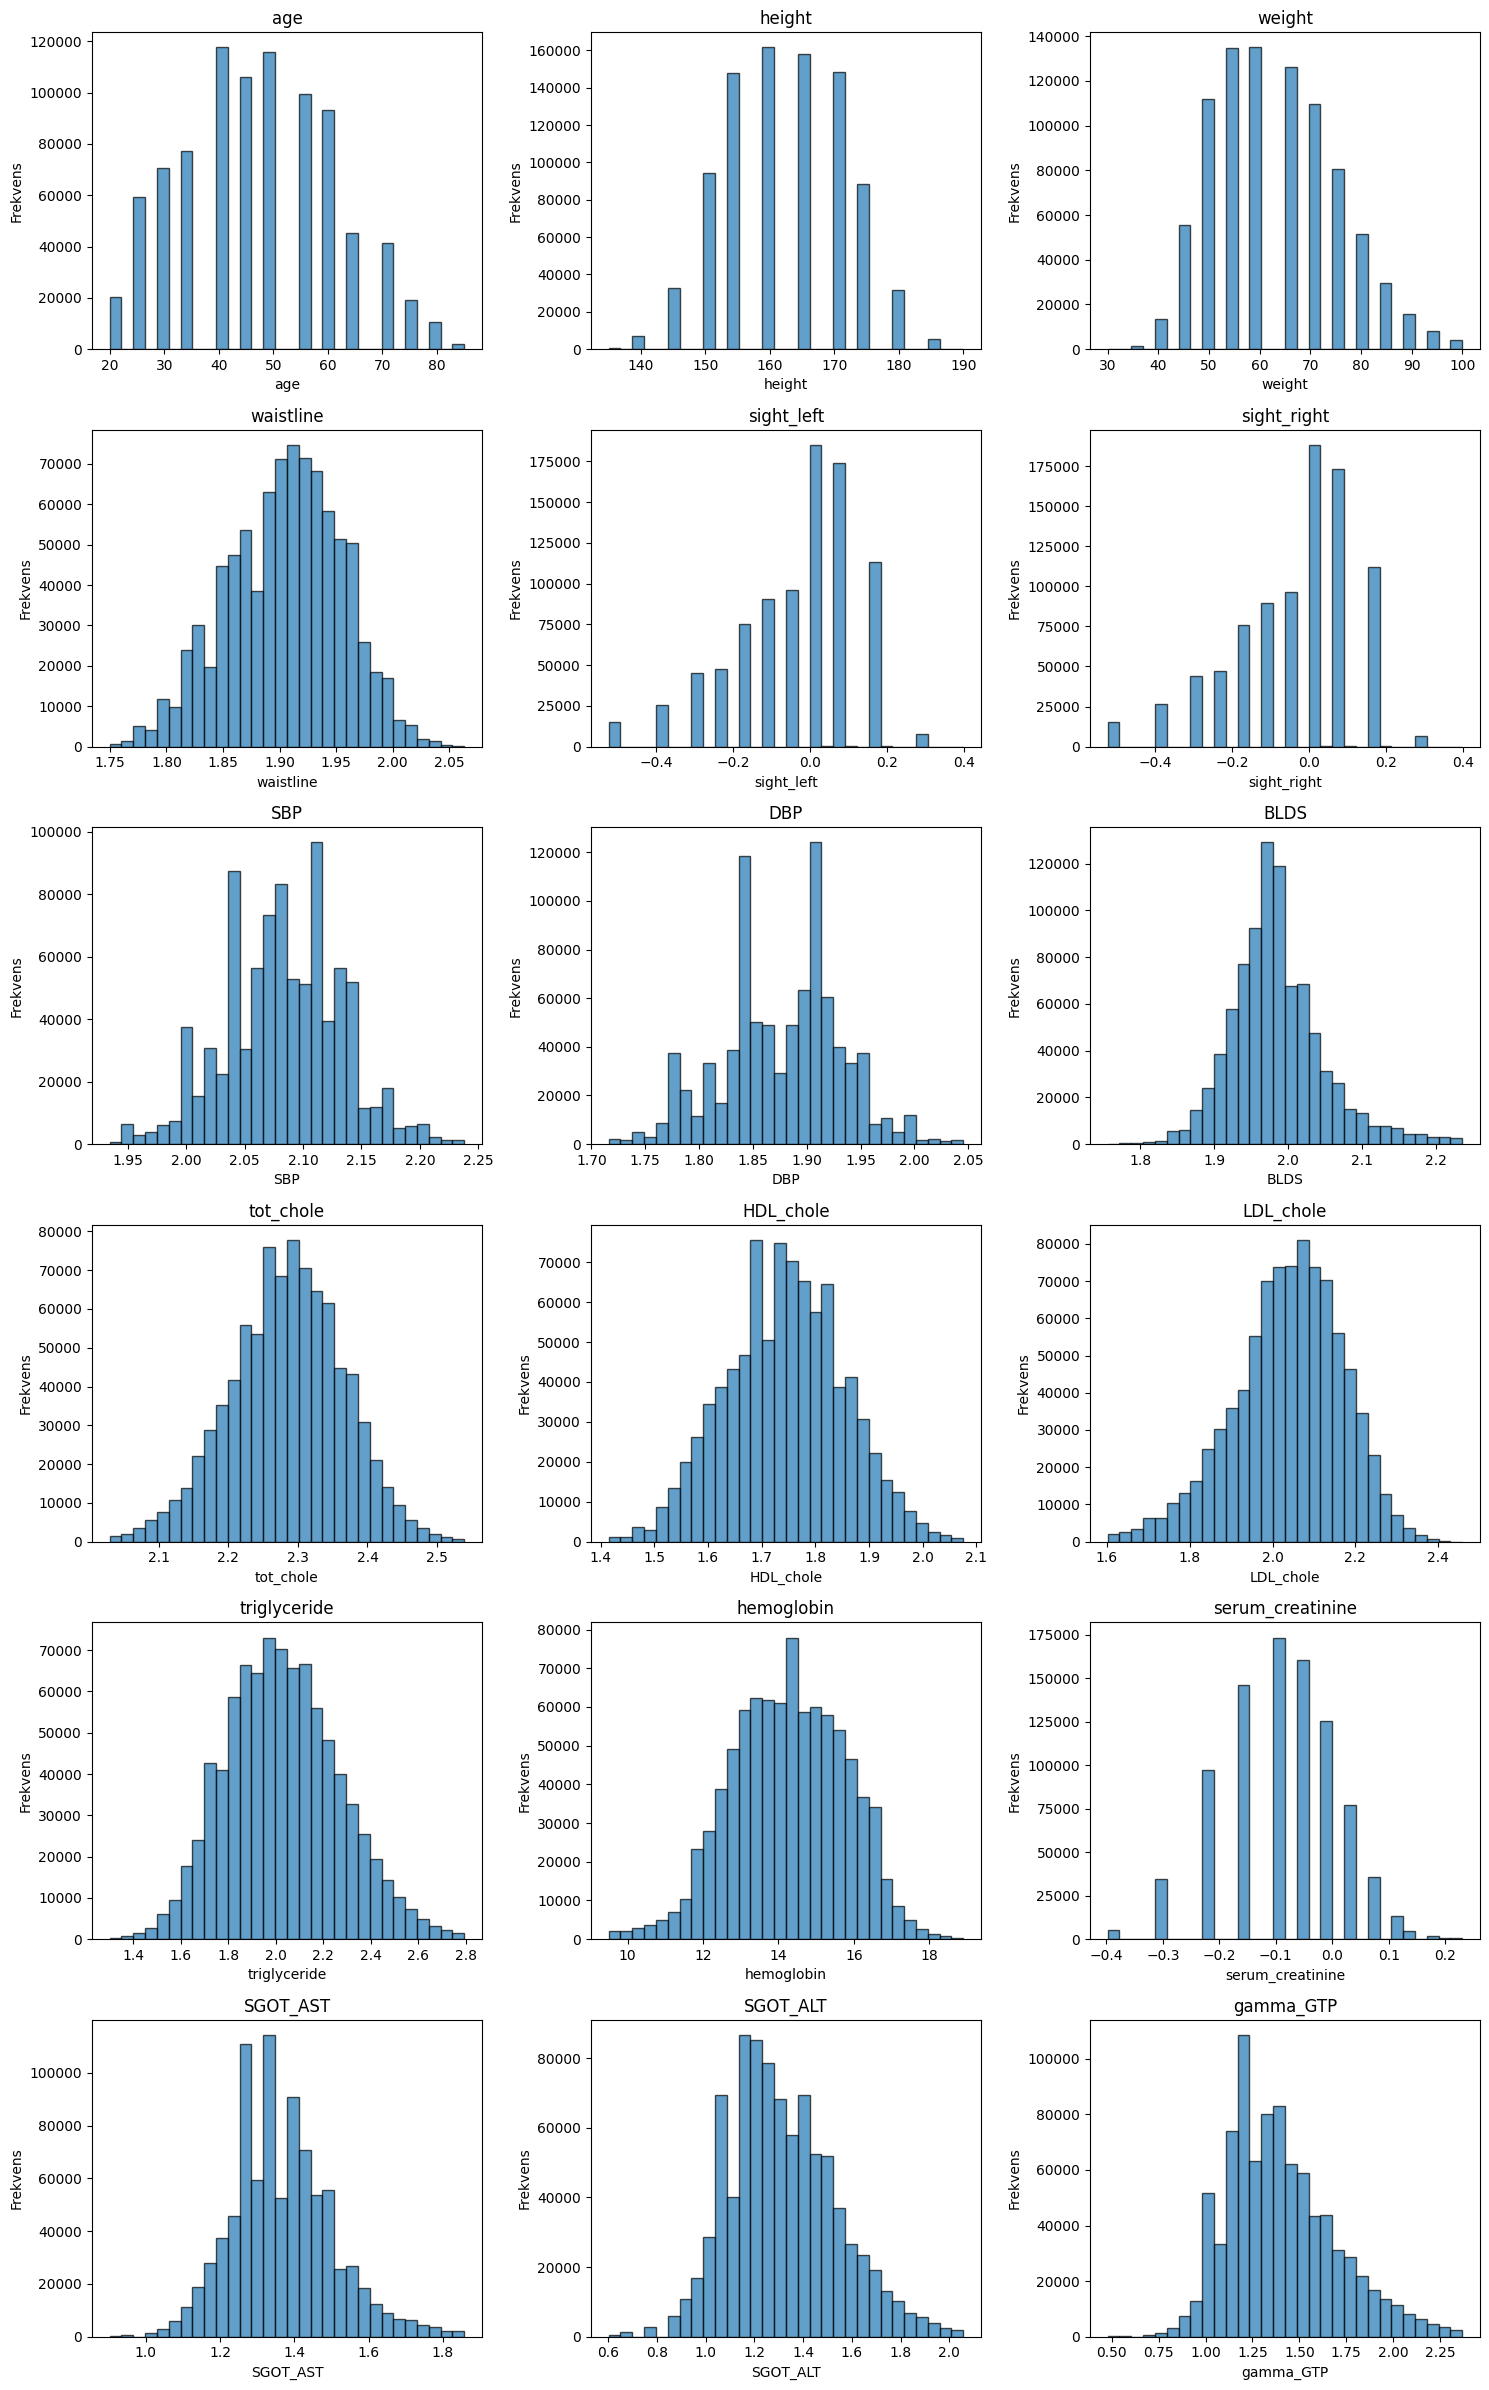

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Bruk df_log (med log-transformerte kolonner)
df = df_log.copy()

# Kolonnene vi faktisk vil sjekke
columns_to_check = [
    "age",
    "height",
    "weight",
    "waistline",
    "sight_left",
    "sight_right",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "hemoglobin",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP",
]

z_scores = df[columns_to_check].apply(zscore)
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()
print(f"Antall rader før: {len(df)}, etter fjerning av outliers: {len(df_clean)}")
n_cols = 3
n_rows = int(np.ceil(len(columns_to_check) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_to_check):
    axes[i].hist(df_clean[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekvens")

# Fjern overflødige subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [17]:
df_clean

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,1.954243,0.000000,0.000000,1.0,1.0,2.079181,...,2.100371,1.963788,17.1,1.0,0.000000,1.322219,1.544068,1.602060,1.0,Y
1,Male,30,180,80,1.949390,-0.045757,0.079181,1.0,1.0,2.113943,...,2.170262,2.082785,15.8,1.0,-0.045757,1.301030,1.556303,1.431364,3.0,N
2,Male,40,165,75,1.959041,0.079181,0.176091,1.0,1.0,2.079181,...,1.869232,2.017033,15.8,1.0,-0.045757,1.672098,1.505150,1.832509,1.0,N
3,Male,50,175,80,1.959041,0.176091,0.079181,1.0,1.0,2.161368,...,2.017033,2.025306,17.6,1.0,0.041393,1.462398,1.531479,1.255273,1.0,N
4,Male,50,165,60,1.903090,0.000000,0.079181,1.0,1.0,2.139879,...,2.068186,2.017033,13.8,1.0,-0.096910,1.278754,1.079181,1.397940,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,1.964260,0.176091,0.176091,1.0,1.0,2.056905,...,2.096910,2.120574,15.0,1.0,0.000000,1.414973,1.556303,1.431364,1.0,N
991342,Male,35,170,75,1.934498,0.000000,0.176091,1.0,1.0,2.075547,...,1.924279,1.653213,15.8,1.0,0.041393,1.146128,1.230449,1.176091,1.0,N
991343,Female,40,155,50,1.832509,0.000000,-0.154902,1.0,1.0,2.041393,...,1.886491,2.195900,14.3,1.0,-0.096910,1.477121,1.431364,1.230449,3.0,Y
991344,Male,25,175,60,1.857332,0.176091,0.000000,1.0,1.0,2.075547,...,1.863323,1.724276,14.5,1.0,-0.096910,1.322219,1.146128,1.230449,1.0,N


In [18]:

df_clean["sex"] = df_clean["sex"].map({"Male": 0, "Female": 1})
df_clean["DRK_YN"] = df_clean["DRK_YN"].map({"N": 0, "Y": 1})

df_clean = df_clean.round(1)

df_clean.to_csv("drinking_df_encoded.csv", index=False)

print("done")


done


In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("drinking_df_encoded.csv")

num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
num_cols = [c for c in num_cols if c != "DRK_YN"]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.to_csv("drinking_df_encoded.csv", index=False)

print("done")


done


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("drinking_df_encoded.csv")

X = df.drop(columns=["DRK_YN"])   
y = df["DRK_YN"]                  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 701614
Test size: 175404


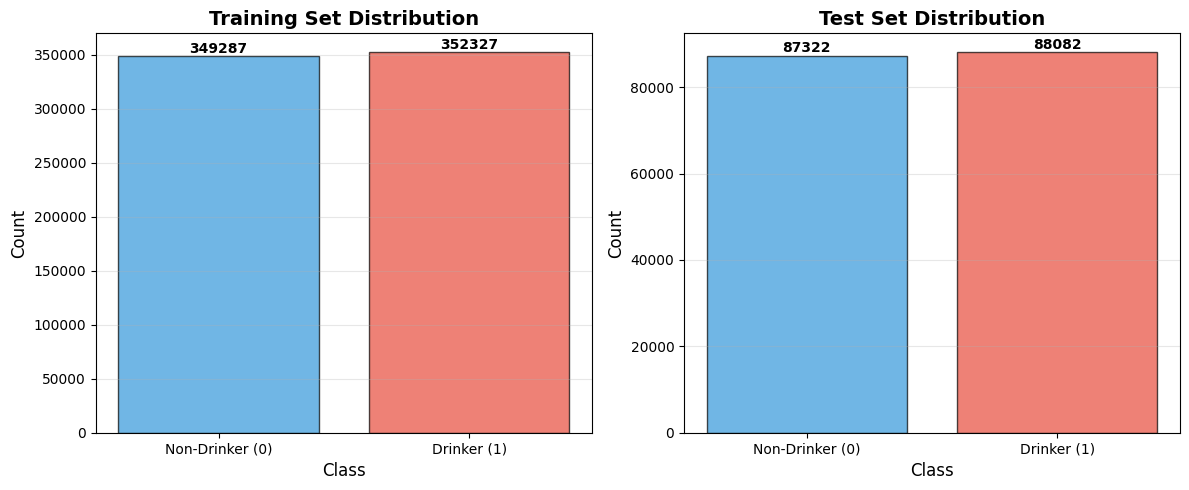

TRAIN-TEST SPLIT DISTRIBUTION

Training Set:
  Non-Drinkers (0): 349287 (49.78%)
  Drinkers (1):     352327 (50.22%)
  Total:            701614

Test Set:
  Non-Drinkers (0): 87322 (49.78%)
  Drinkers (1):     88082 (50.22%)
  Total:            175404


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set distribution
train_counts = y_train.value_counts().sort_index()
train_labels = ['Non-Drinker (0)', 'Drinker (1)']
axes[0].bar(train_labels, train_counts.values, color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
test_counts = y_test.value_counts().sort_index()
test_labels = ['Non-Drinker (0)', 'Drinker (1)']
axes[1].bar(test_labels, test_counts.values, color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*60)
print("TRAIN-TEST SPLIT DISTRIBUTION")
print("="*60)
print("\nTraining Set:")
print(f"  Non-Drinkers (0): {train_counts[0]} ({train_counts[0]/len(y_train)*100:.2f}%)")
print(f"  Drinkers (1):     {train_counts[1]} ({train_counts[1]/len(y_train)*100:.2f}%)")
print(f"  Total:            {len(y_train)}")

print("\nTest Set:")
print(f"  Non-Drinkers (0): {test_counts[0]} ({test_counts[0]/len(y_test)*100:.2f}%)")
print(f"  Drinkers (1):     {test_counts[1]} ({test_counts[1]/len(y_test)*100:.2f}%)")
print(f"  Total:            {len(y_test)}")
print("="*60)

TRAIN-TEST FEATURE STATISTICS COMPARISON

Mean Values:
         Feature  Train Mean  Test Mean  Mean Diff
             age    0.416248   0.417065   0.000817
          height    0.497120   0.496568   0.000552
          weight    0.472404   0.472104   0.000300
       waistline    0.507584   0.507873   0.000289
             SBP    0.598220   0.598065   0.000155
             DBP    0.573989   0.574588   0.000599
            BLDS    0.461137   0.461653   0.000516
       tot_chole    0.570744   0.570965   0.000221
       HDL_chole    0.491125   0.491650   0.000525
       LDL_chole    0.486207   0.486028   0.000178
    triglyceride    0.486396   0.487076   0.000680
      hemoglobin    0.506312   0.506465   0.000153
serum_creatinine    0.528745   0.529267   0.000521

Standard Deviation:
         Feature  Train Std  Test Std  Std Diff
             age   0.214064  0.214395  0.000331
          height   0.167203  0.167151  0.000051
          weight   0.171713  0.171092  0.000620
       waistline  

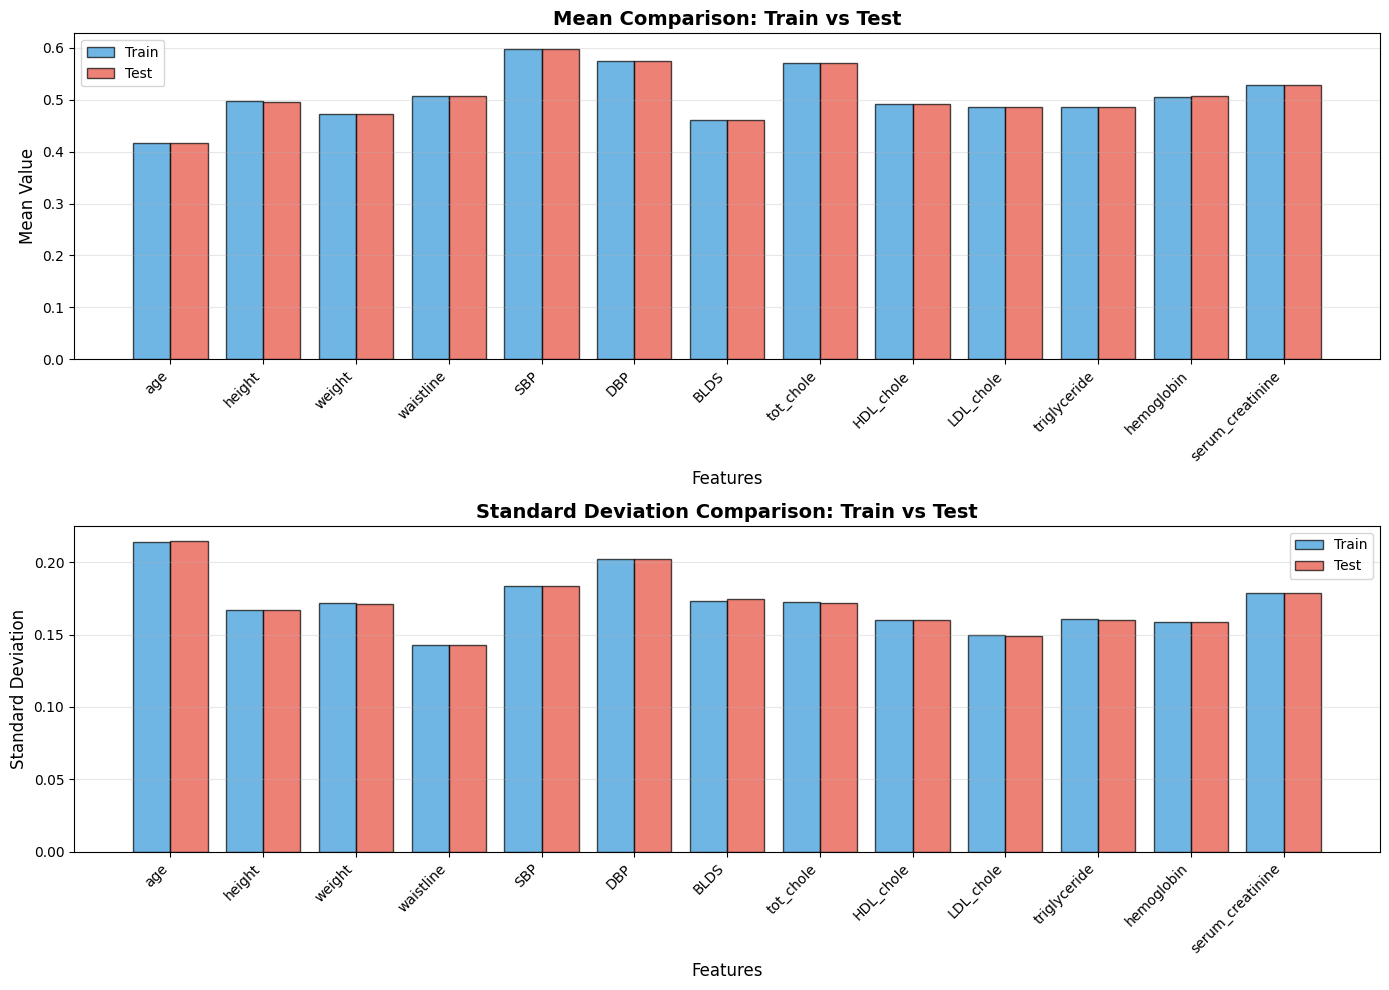


SUMMARY STATISTICS
Maximum mean difference: 0.000817
Average mean difference: 0.000424
Maximum std difference: 0.000739
Average std difference: 0.000327

Feature with largest mean difference:
  age: 0.000817


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate statistics for key features
key_features = ['age', 'height', 'weight', 'waistline', 'SBP', 'DBP', 
                'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 
                'triglyceride', 'hemoglobin', 'serum_creatinine']

# Create comparison dataframe
stats_comparison = []

for feature in key_features:
    if feature in X_train.columns:
        train_mean = X_train[feature].mean()
        test_mean = X_test[feature].mean()
        train_std = X_train[feature].std()
        test_std = X_test[feature].std()
        
        stats_comparison.append({
            'Feature': feature,
            'Train Mean': train_mean,
            'Test Mean': test_mean,
            'Mean Diff': abs(train_mean - test_mean),
            'Train Std': train_std,
            'Test Std': test_std,
            'Std Diff': abs(train_std - test_std)
        })

stats_df = pd.DataFrame(stats_comparison)

# Print detailed statistics
print("="*80)
print("TRAIN-TEST FEATURE STATISTICS COMPARISON")
print("="*80)
print("\nMean Values:")
print(stats_df[['Feature', 'Train Mean', 'Test Mean', 'Mean Diff']].to_string(index=False))
print("\nStandard Deviation:")
print(stats_df[['Feature', 'Train Std', 'Test Std', 'Std Diff']].to_string(index=False))

# Visualize mean comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Mean comparison
x = range(len(key_features))
axes[0].bar([i - 0.2 for i in x], stats_df['Train Mean'], width=0.4, 
            label='Train', color='#3498db', alpha=0.7, edgecolor='black')
axes[0].bar([i + 0.2 for i in x], stats_df['Test Mean'], width=0.4, 
            label='Test', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Features', fontsize=12)
axes[0].set_ylabel('Mean Value', fontsize=12)
axes[0].set_title('Mean Comparison: Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(key_features, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Standard deviation comparison
axes[1].bar([i - 0.2 for i in x], stats_df['Train Std'], width=0.4, 
            label='Train', color='#3498db', alpha=0.7, edgecolor='black')
axes[1].bar([i + 0.2 for i in x], stats_df['Test Std'], width=0.4, 
            label='Test', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Features', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].set_title('Standard Deviation Comparison: Train vs Test', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(key_features, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display maximum differences
max_mean_diff = stats_df['Mean Diff'].max()
max_std_diff = stats_df['Std Diff'].max()
avg_mean_diff = stats_df['Mean Diff'].mean()
avg_std_diff = stats_df['Std Diff'].mean()

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Maximum mean difference: {max_mean_diff:.6f}")
print(f"Average mean difference: {avg_mean_diff:.6f}")
print(f"Maximum std difference: {max_std_diff:.6f}")
print(f"Average std difference: {avg_std_diff:.6f}")
print("\nFeature with largest mean difference:")
print(f"  {stats_df.loc[stats_df['Mean Diff'].idxmax(), 'Feature']}: {max_mean_diff:.6f}")
print("="*80)

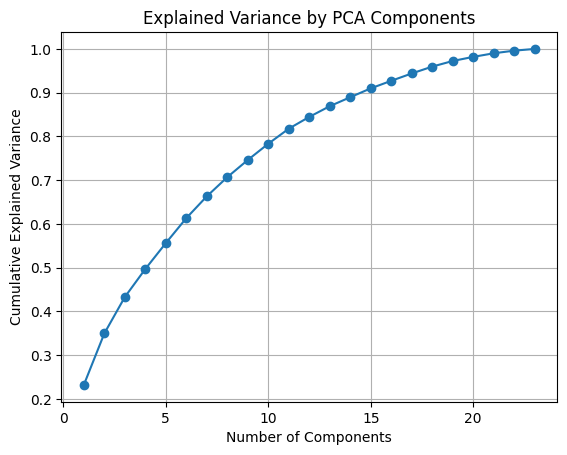

Antall komponenter for å forklare 80% av variansen: 11


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X = numeriske features uten target
X = df_clean.drop(columns=["DRK_YN"])
X_scaled = StandardScaler().fit_transform(X)

# PCA på alle features
pca = PCA()
pca.fit(X_scaled)

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

# Hvor mange trengs for 80%?
n_components_80 = np.argmax(cum_var >= 0.8) + 1
print(f"Antall komponenter for å forklare 80% av variansen: {n_components_80}")


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X = numeriske features uten target
X = df_clean.drop(columns=["DRK_YN"])
X_scaled = StandardScaler().fit_transform(X)

# Behold 11 komponenter
pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_scaled)

# Lag nytt DataFrame
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(11)])
print(pca_df.head())


        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.482451 -0.634344  0.299190  0.123768 -0.656999 -0.160586  0.029712   
1 -3.002394 -1.616249  1.299587  0.901525 -0.724579 -0.488462  0.376479   
2 -2.621875 -0.713376 -1.812899 -1.266098  1.881377  0.901396 -0.765546   
3 -2.863746 -0.605448  0.273772 -0.489527 -0.928507  1.469764  1.305942   
4  0.275277 -0.494290  0.468565  0.113883 -1.036956  0.415772  0.142637   

        PC8       PC9      PC10      PC11  
0 -0.364175 -1.020115  0.823535  0.322997  
1 -0.146037  0.049133 -0.006659 -0.574398  
2 -0.414802 -0.914388  0.466795  1.346132  
3 -0.290288 -0.906498  1.458651  1.088488  
4 -0.010484  0.389703  0.466294  0.395822  
